In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Service Logic (M/M/s Core Formulas)

In [3]:
def calculateP0(lambd, mu, s):
    sumTerm = sum([(lambd / mu) ** n / math.factorial(n) for n in range(s)])
    lastTerm = ((lambd / mu) ** s) / (math.factorial(s) * (1 - (lambd / (s * mu))))
    return 1 / (sumTerm + lastTerm)

def calculateLq(lambd, mu, s, p0, rho):
    numerator = p0 * ((lambd / mu) ** s) * rho
    denominator = math.factorial(s) * ((1 - rho) ** 2)
    return numerator / denominator

def calculateQueueMetrics(row, sOverride=None):
    lambd = row['lambda_arrival']
    mu = row['mu_service']
    s = sOverride if sOverride is not None else row['cs_count']
    
    rho = lambd / (s * mu)
    if rho >= 1:
        return pd.Series([rho, 1.0, np.inf, np.inf, np.inf, np.inf])
        
    p0 = calculateP0(lambd, mu, s)
    lq = calculateLq(lambd, mu, s, p0, rho)
    ls = lq + (lambd / mu)
    wq = (lq / lambd) * 60 
    ws = (ls / lambd) * 60 
    
    return pd.Series([rho, p0, lq, ls, wq, ws])

# Data Loading, Execution, and Validation

In [6]:
dfAntrean = pd.read_csv('data_antrean.csv')
dfValidasiJurnal = pd.read_csv('data_validasi.csv')

metricsCols = ['rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']

dfRiyals = dfAntrean.copy()
dfRiyals[metricsCols] = dfRiyals.apply(calculateQueueMetrics, axis=1)

dfSkenarioBaru = dfAntrean.copy()
dfSkenarioBaru[metricsCols] = dfSkenarioBaru.apply(lambda row: calculateQueueMetrics(row, sOverride=2), axis=1)

dfValidationComparison = pd.DataFrame({
    'blok_jam': dfRiyals['blok_jam'],
    'rho_python': dfRiyals['rho'],
    'rho_jurnal': dfValidasiJurnal['rho_jurnal'],
    'wq_python_minutes': dfRiyals['wq_minutes'],
    'wq_jurnal_minutes': dfValidasiJurnal['wq_jurnal'],
    'ws_python_minutes': dfRiyals['ws_minutes'],
    'ws_jurnal_minutes': dfValidasiJurnal['ws_jurnal']
})

dfValidationComparison['error_wq'] = np.abs(dfValidationComparison['wq_python_minutes'] - dfValidationComparison['wq_jurnal_minutes'])

print("--- TABEL VALIDASI KOMPARASI ---")
print(dfValidationComparison[['blok_jam', 'wq_python_minutes', 'wq_jurnal_minutes', 'error_wq']])

--- TABEL VALIDASI KOMPARASI ---
  blok_jam  wq_python_minutes  wq_jurnal_minutes   error_wq
0        A           6.428571               15.0   8.571429
1        B          12.500000               20.0   7.500000
2        C          12.500000               20.0   7.500000
3        D           4.500000               12.0   7.500000
4        E           5.000000               15.0  10.000000
5        F           3.428571               12.0   8.571429


# Visualisasi

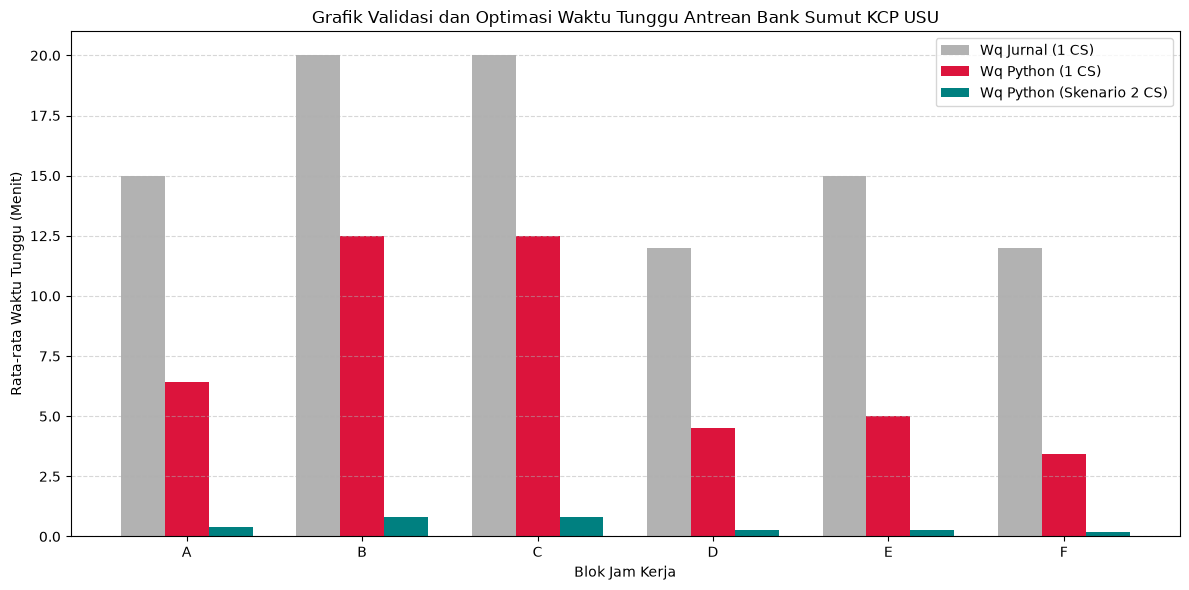

In [8]:
plt.figure(figsize=(12, 6))
x = np.arange(len(dfAntrean['blok_jam']))
width = 0.25

plt.bar(x - width, dfValidationComparison['wq_jurnal_minutes'], width, label='Wq Jurnal (1 CS)', color='gray', alpha=0.6)
plt.bar(x, dfValidationComparison['wq_python_minutes'], width, label='Wq Python (1 CS)', color='crimson')
plt.bar(x + width, dfSkenarioBaru['wq_minutes'], width, label='Wq Python (Skenario 2 CS)', color='teal')

plt.xlabel('Blok Jam Kerja')
plt.ylabel('Rata-rata Waktu Tunggu (Menit)')
plt.title('Grafik Validasi dan Optimasi Waktu Tunggu Antrean Bank Sumut KCP USU')
plt.xticks(x, dfAntrean['blok_jam'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()